In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("UberDataset.csv") 

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [4]:
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [5]:
print("\nMissing Values:") 
print(df.isnull().sum()) 


Missing Values:
START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64


In [6]:
df['PURPOSE'].fillna('Unknown', inplace=True) 

In [7]:
df.dropna(subset=['START_DATE', 'END_DATE'], inplace=True) 

In [8]:
# datatype conversion 
df['START_DATE'] = pd.to_datetime(df['START_DATE']) 
df['END_DATE'] = pd.to_datetime(df['END_DATE']) 

In [9]:
# feature engineering
df['DURATION'] = (df['END_DATE'] - df['START_DATE']).dt.total_seconds() / 60 
df['MONTH'] = df['START_DATE'].dt.month 
df['DAY'] = df['START_DATE'].dt.day_name() 
df['HOUR'] = df['START_DATE'].dt.hour 

In [10]:
# KPI's 
print("\n📊KPI Metrics")
print("Total Trips:", len(df))
print("Total Distance (Miles):", df['MILES'].sum().round(2))
print("Average Distance (Miles):", df['MILES'].mean().round(2))
print("Average Duration (Minutes):", df['DURATION'].mean().round(2)) 


📊KPI Metrics
Total Trips: 1155
Total Distance (Miles): 12204.7
Average Distance (Miles): 10.57
Average Duration (Minutes): 23.24


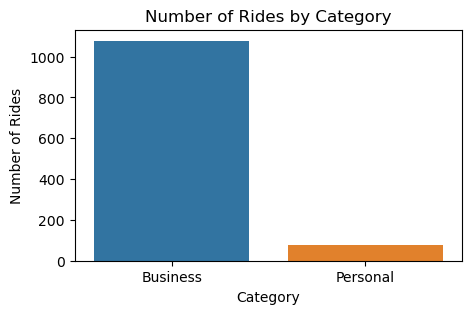

In [11]:
# 1. 
plt.figure(figsize=(5,3)) 
sns.countplot(x='CATEGORY', data=df)
plt.title("Number of Rides by Category") 
plt.xlabel("Category") 
plt.ylabel("Number of Rides") 
plt.show() 

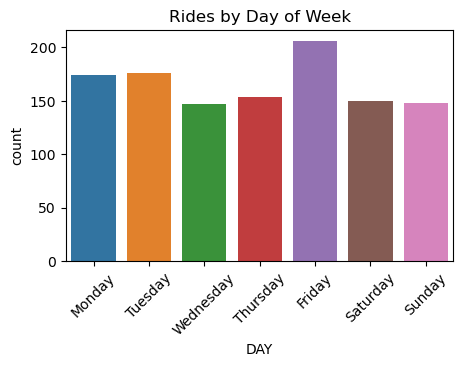

In [12]:
# 2. 
plt.figure(figsize=(5,3)) 
sns.countplot( 
    x='DAY', 
    data=df, 
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title("Rides by Day of Week") 
plt.xticks(rotation=45) 
plt.show() 

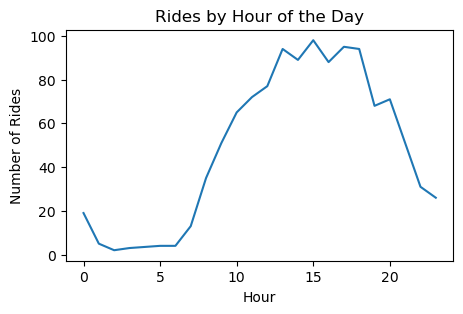

In [13]:
# 3. 
hour_data = df['HOUR'].value_counts().sort_index() 
plt.figure(figsize=(5,3)) 
plt.plot(hour_data.index, hour_data.values) 
plt.title("Rides by Hour of the Day") 
plt.xlabel("Hour") 
plt.ylabel("Number of Rides") 
plt.show() 

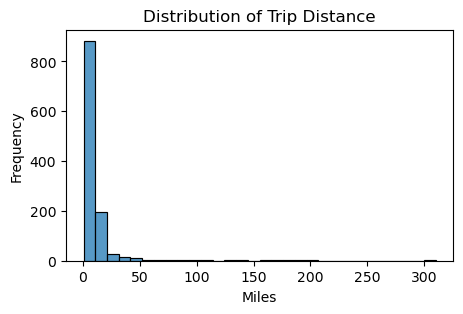

In [14]:
# 4. 
plt.figure(figsize=(5,3)) 
sns.histplot(df['MILES'], bins=30) 
plt.title("Distribution of Trip Distance") 
plt.xlabel("Miles") 
plt.ylabel("Frequency") 
plt.show() 

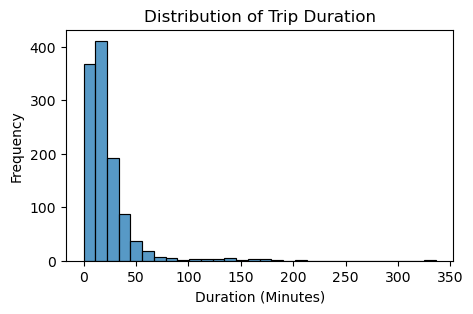

In [15]:
# 5. 
plt.figure(figsize=(5,3)) 
sns.histplot(df['DURATION'], bins=30) 
plt.title("Distribution of Trip Duration") 
plt.xlabel("Duration (Minutes)") 
plt.ylabel("Frequency") 
plt.show() 